# Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import cv2
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_img_dir = "/content/drive/MyDrive/DATA/Eyes data/train/image"
train_mask_dir = "/content/drive/MyDrive/DATA/Eyes data/train/mask"

In [4]:

# Function to display image and mask side by side
def display_image_and_mask(img_path, mask_path):
    img = Image.open(img_path)
    mask = Image.open(mask_path)

    # Plot the image and the mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    plt.show()


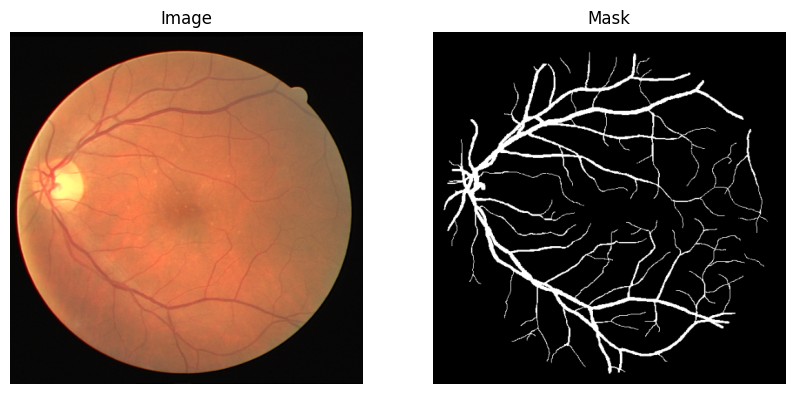

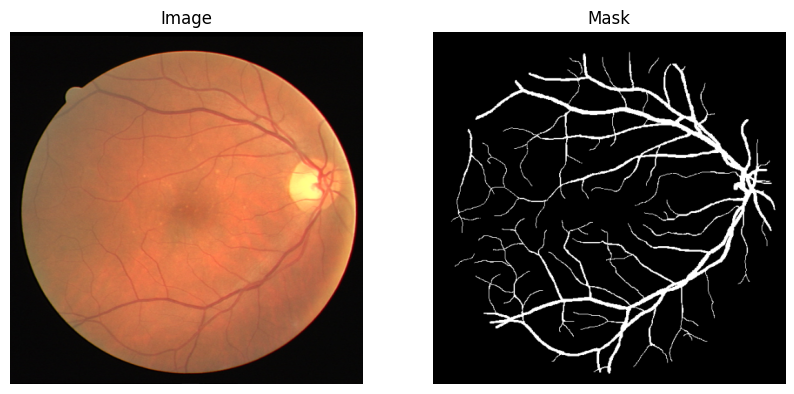

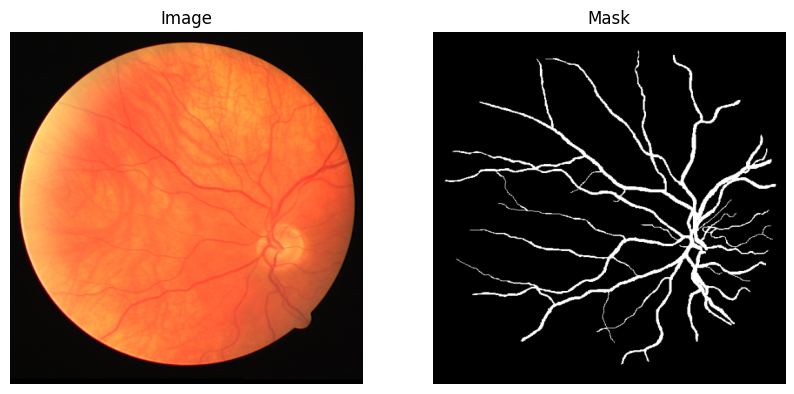

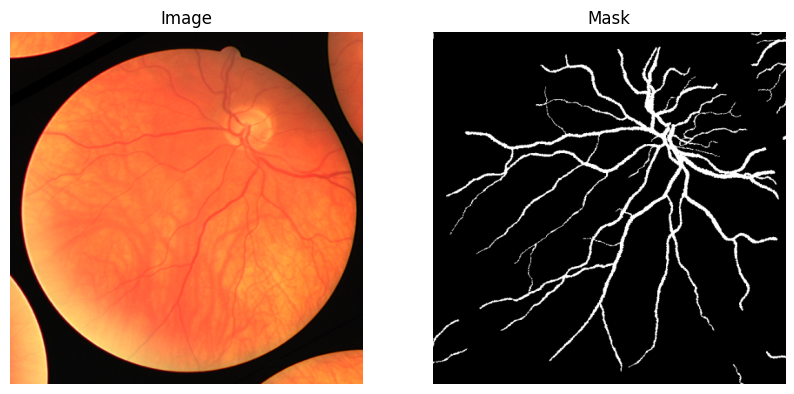

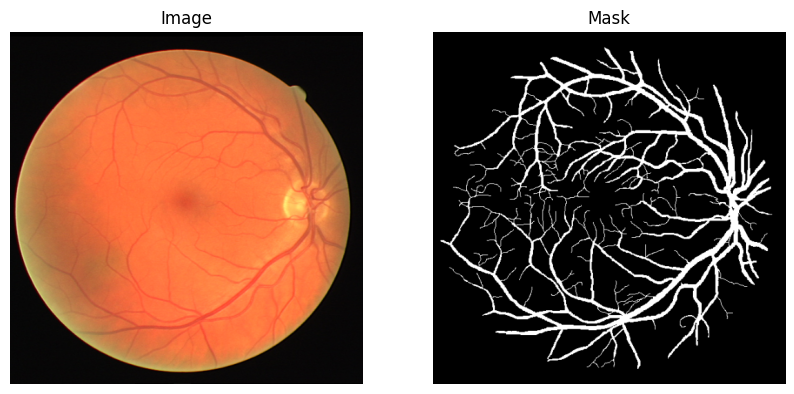

In [5]:

# Get image and mask filenames and sort them to ensure matching
train_img_files = sorted(os.listdir(train_img_dir))
train_mask_files = sorted(os.listdir(train_mask_dir))

# Check that the number of images matches the number of masks
if len(train_img_files) != len(train_mask_files):
    print("Error: The number of images and masks do not match!")
else:
    # Display only the first 5 image-mask pairs
    for img_file, mask_file in zip(train_img_files[:5], train_mask_files[:5]):
        # Construct the full file paths
        img_path = os.path.join(train_img_dir, img_file)
        mask_path = os.path.join(train_mask_dir, mask_file)

        # Display the image and mask together
        display_image_and_mask(img_path, mask_path)

# New

In [ ]:
images = [os.path.join(train_img_dir, file) for file in os.listdir(train_img_dir)]
masks = [os.path.join(train_mask_dir, file) for file in os.listdir(train_mask_dir)]

data = pd.DataFrame({"image": images, "mask": masks})

train_df, val_df = train_test_split(data, train_size=0.8, shuffle=True, random_state=123)

In [ ]:
image_datagen = ImageDataGenerator(rescale=1./255)
mask_datagen = ImageDataGenerator(rescale=1./255)

def create_generator(image_generator, mask_generator, batch_size=16):
    while True:
        for (img_batch, mask_batch) in zip(image_generator, mask_generator):
            yield img_batch, mask_batch

In [ ]:
train_image_generator = image_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image",
    y_col=None,
    target_size=(128, 128),
    batch_size=16,
    class_mode=None,
    color_mode='rgb',
    shuffle=True,
    seed=42
)

train_mask_generator = mask_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="mask",
    y_col=None,
    target_size=(128, 128),
    batch_size=16,
    class_mode=None,
    color_mode='grayscale',
    shuffle=True,
    seed=42
)

train_generator = create_generator(train_image_generator, train_mask_generator)


Found 64 validated image filenames.
Found 64 validated image filenames.


In [ ]:
val_image_generator = image_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image",
    y_col=None,
    target_size=(128, 128),
    batch_size=16,
    class_mode=None,
    color_mode='rgb',
    shuffle=False,  # Validation data should not be shuffled
    seed=42
)

val_mask_generator = mask_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="mask",
    y_col=None,
    target_size=(128, 128),
    batch_size=16,
    class_mode=None,
    color_mode='grayscale',
    shuffle=False,  # Validation data should not be shuffled
    seed=42
)

val_generator = create_generator(val_image_generator, val_mask_generator)

Found 16 validated image filenames.
Found 16 validated image filenames.


In [ ]:
def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)


    # Decoder
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # Output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs])

    return model

In [ ]:
model = unet_model(input_size=(128, 128, 3))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    steps_per_epoch=len(train_df) // 16,
    validation_steps=len(val_df) // 16
)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_133 (Conv2D)       │ (None, 128, 128, 64)   │          1,792 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_134 (Conv2D)       │ (None, 128, 128, 64)   │         36,928 │ conv2d_133[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_28          │ (None, 64, 64, 64)     │              0 │ conv2d_134[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_135 (Conv2D)       │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_28[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_136 (Conv2D)       │ (None, 64, 64, 128)    │        147,584 │ conv2d_135[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_29          │ (None, 32, 32, 128)    │              0 │ conv2d_136[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_137 (Conv2D)       │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_29[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_138 (Conv2D)       │ (None, 32, 32, 256)    │        590,080 │ conv2d_137[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_30          │ (None, 16, 16, 256)    │              0 │ conv2d_138[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_139 (Conv2D)       │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_30[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_140 (Conv2D)       │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_139[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_31          │ (None, 8, 8, 512)      │              0 │ conv2d_140[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_141 (Conv2D)       │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_31[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_142 (Conv2D)       │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_141[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_28       │ (None, 16, 16, 512)    │      2,097,664 │ conv2d_142[0][0]       │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_28       

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 172s 20s/step - accuracy: 0.8511 - loss: 0.6804 - val_accuracy: 0.8743 - val_loss: 0.6654
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 80s 20s/step - accuracy: 0.8782 - loss: 0.6584 - val_accuracy: 0.8743 - val_loss: 0.6410
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 78s 20s/step - accuracy: 0.8745 - loss: 0.6311 - val_accuracy: 0.8743 - val_loss: 0.5948
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 80s 21s/step - accuracy: 0.8778 - loss: 0.5654 - val_accuracy: 0.8743 - val_loss: 0.4498
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 80s 21s/step - accuracy: 0.8787 - loss: 0.4366 - val_accuracy: 0.8743 - val_loss: 0.4250


In [ ]:
loss, accuracy = model.evaluate(val_generator, steps=50)
print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')

50/50 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.8743 - loss: 0.4250
Validation Loss: 0.4249788224697113
Validation Accuracy: 0.8743324279785156


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


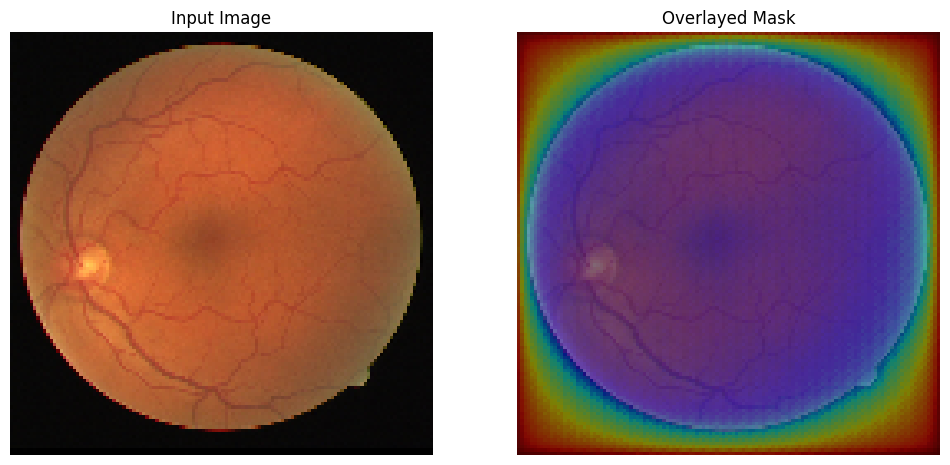

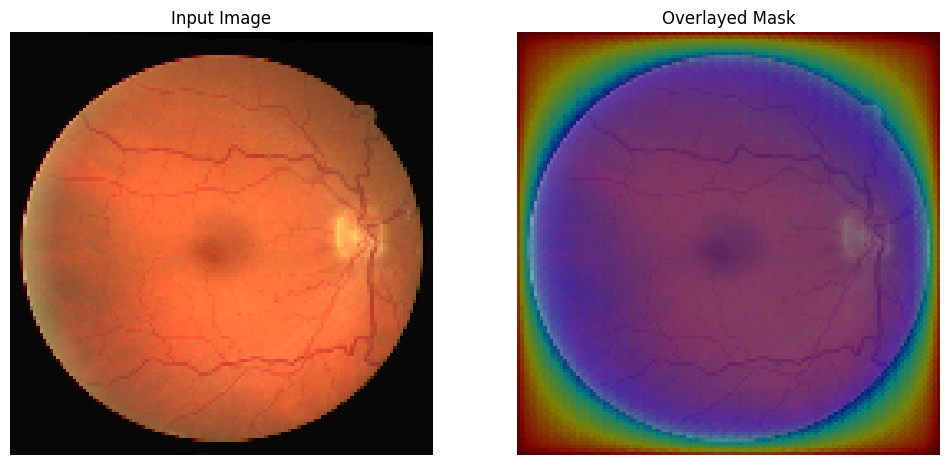

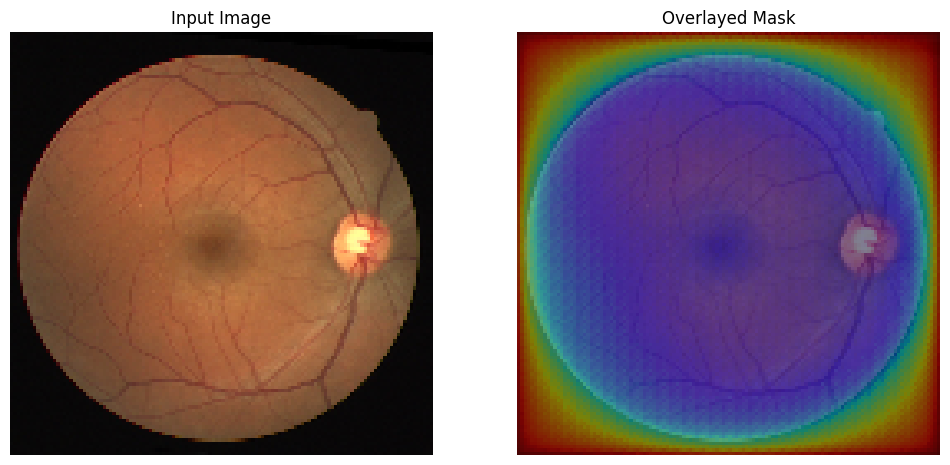

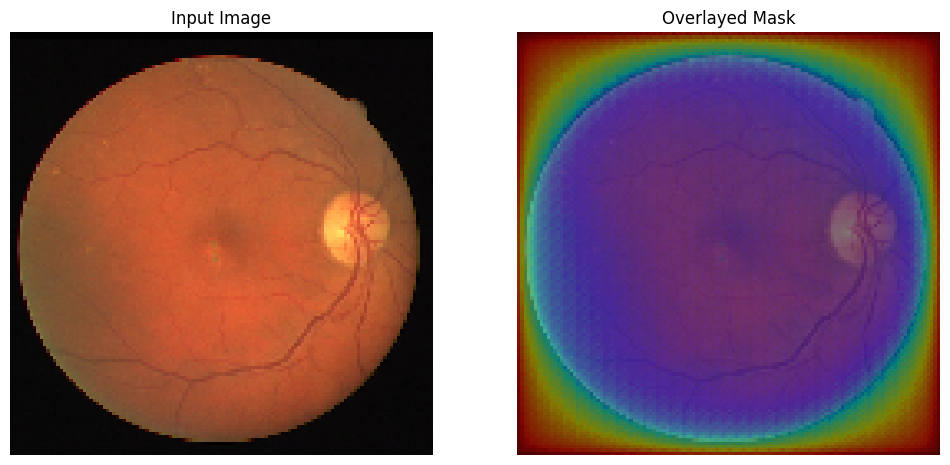

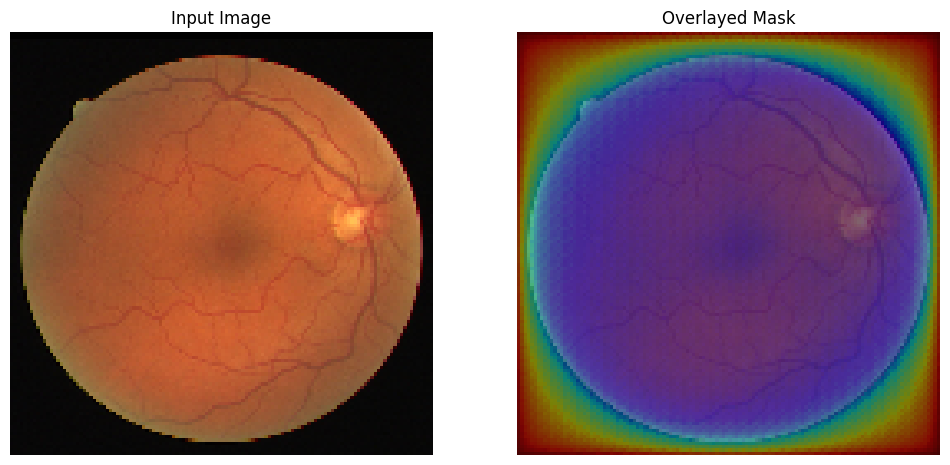

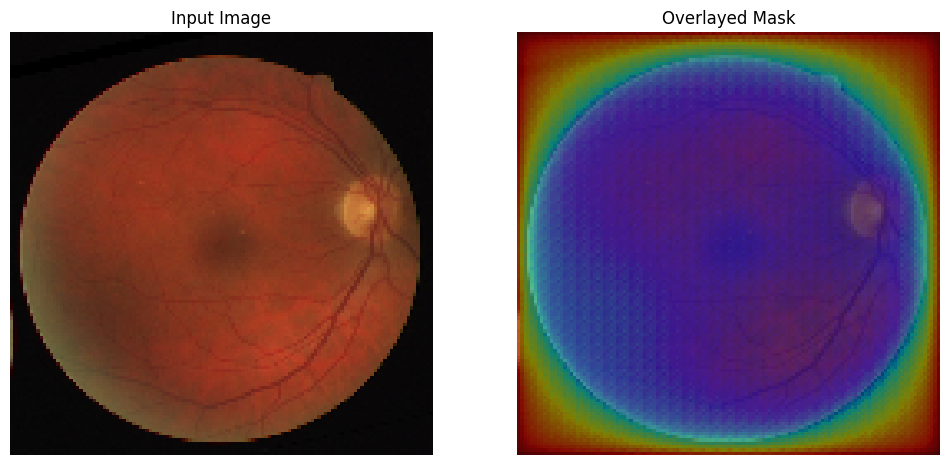

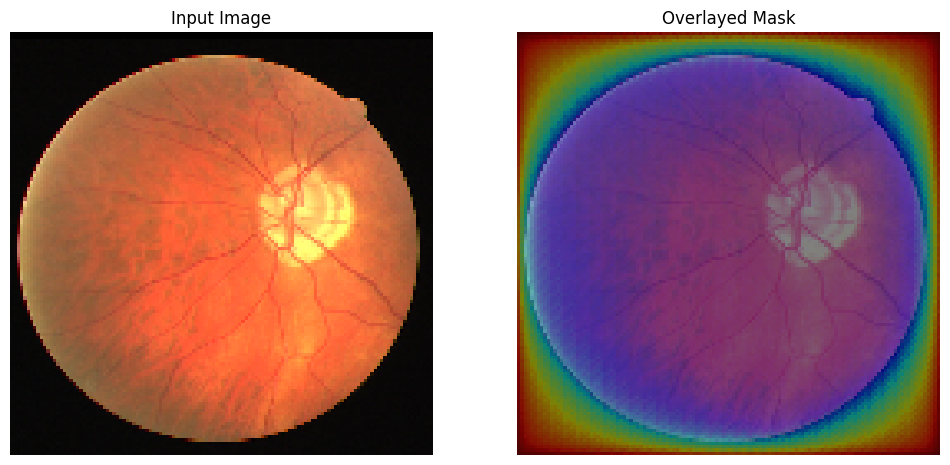

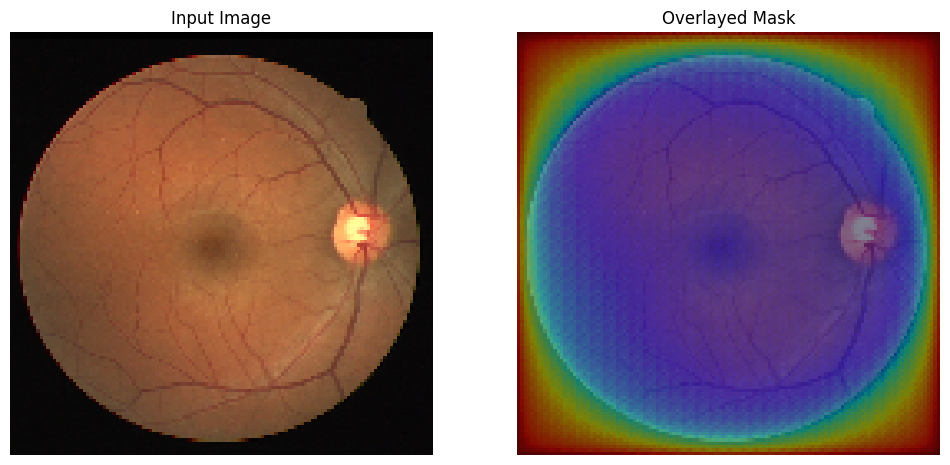

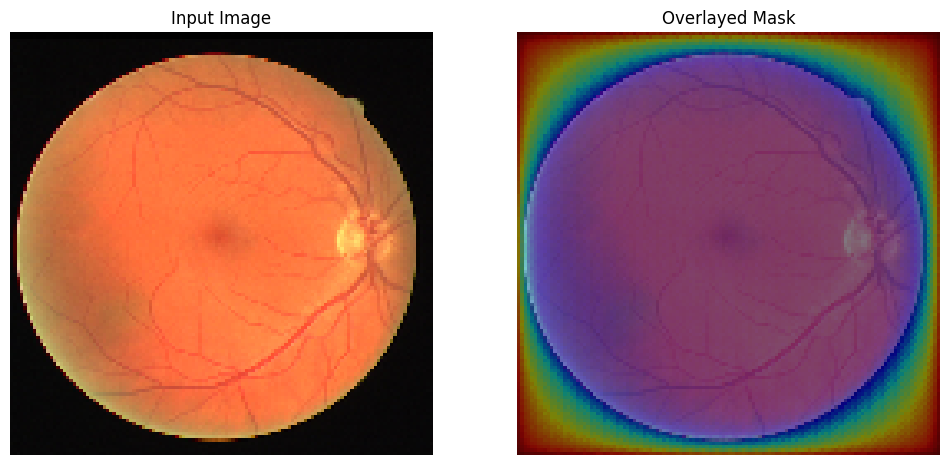

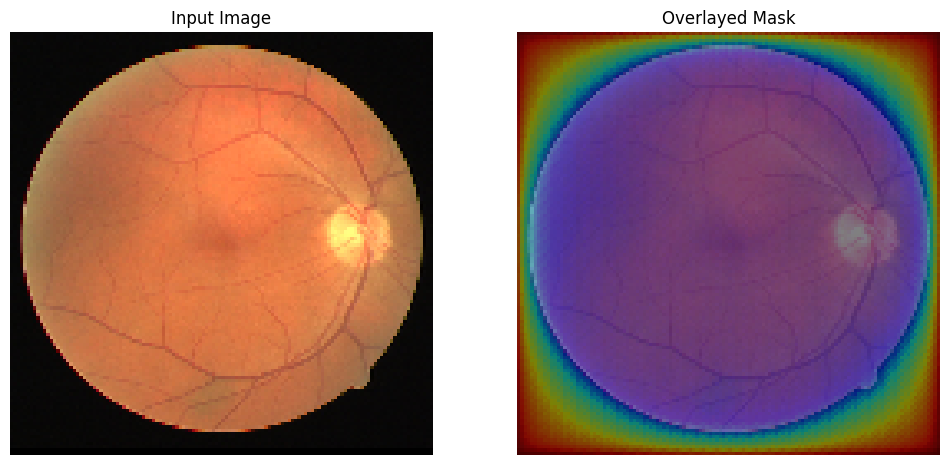

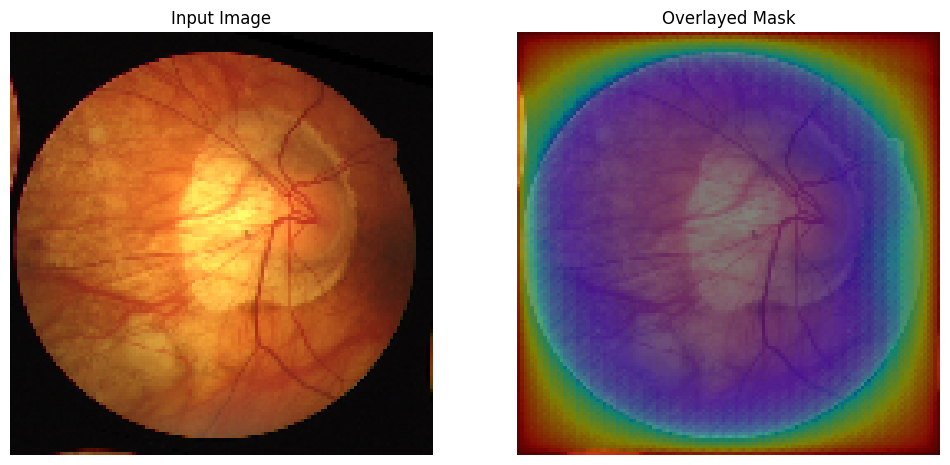

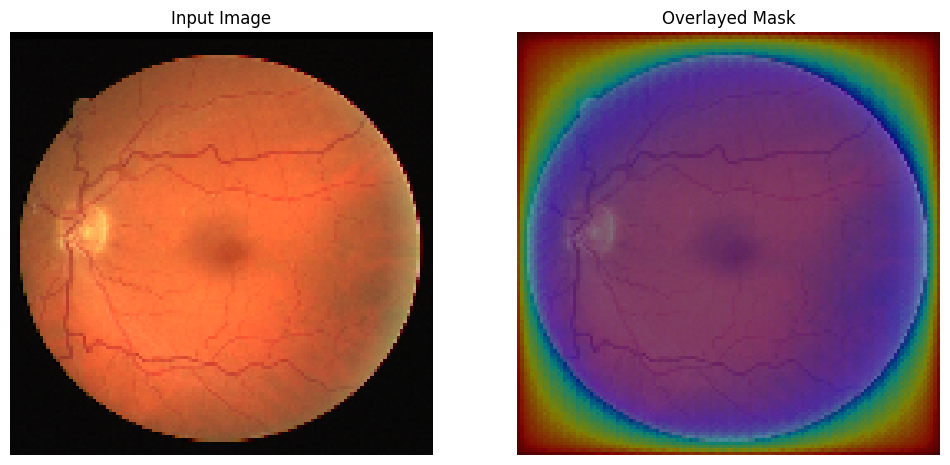

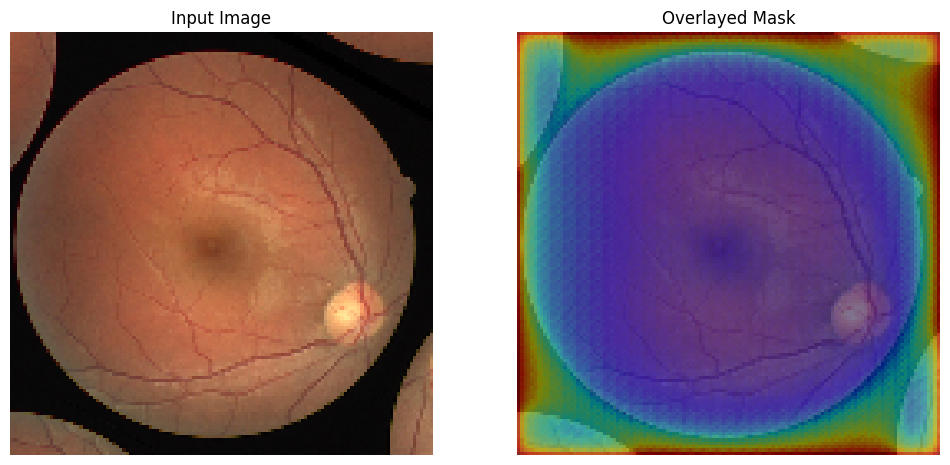

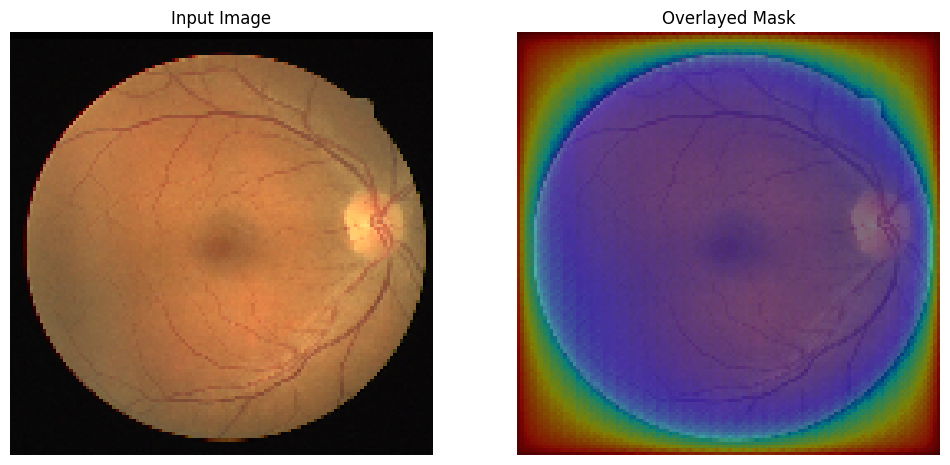

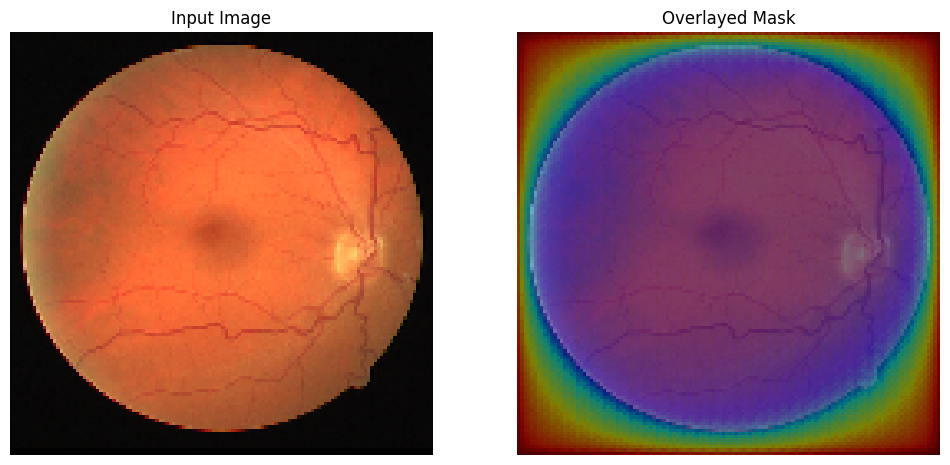

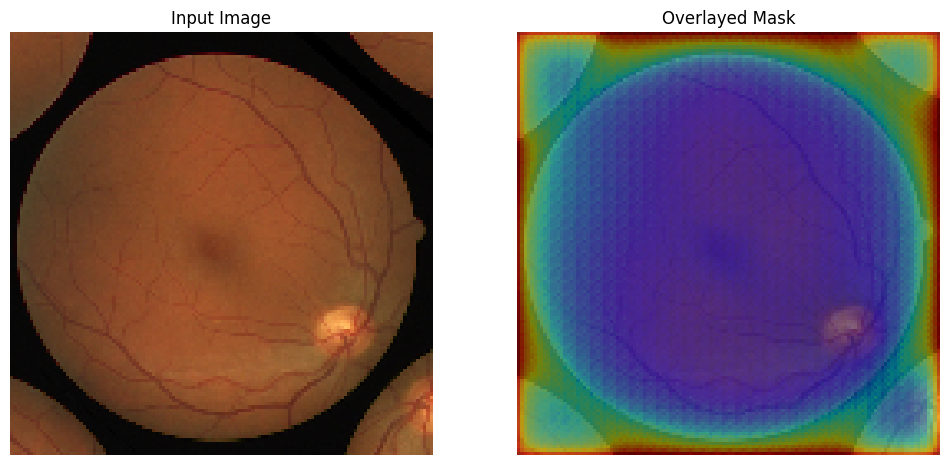

In [ ]:
# def overlay_predictions(model, generator, alpha=0.5):
#     images, masks = next(generator)
#     predictions = model.predict(images)

#     for i in range(len(images)):
#         plt.figure(figsize=(12, 6))

#         plt.subplot(1, 2, 1)
#         plt.title("Input Image")
#         plt.imshow(images[i])
#         plt.axis('off')

#         plt.subplot(1, 2, 2)
#         plt.title("Overlayed Mask")
#         plt.imshow(images[i])
#         plt.imshow(predictions[i].squeeze(), cmap='jet', alpha=alpha)
#         plt.axis('off')

#         plt.show()

# overlay_predictions(model, val_generator)